## Imports

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.21.0
GPU Available: 0


## Dataset Paths and Configuration

In [16]:
TRAIN_DIR = "../classification/train"
VALID_DIR = "../classification/val"
TEST_DIR = "../classification/test"

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 40
LEARNING_RATE = 1e-4
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Data Augmentation

In [17]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

## Load Data

In [18]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print(train_generator.class_indices)

Found 1820 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
{'airplane': 0, 'bed': 1, 'bench': 2, 'bicycle': 3, 'bird': 4, 'bottle': 5, 'bowl': 6, 'bus': 7, 'cake': 8, 'car': 9, 'cat': 10, 'chair': 11, 'couch': 12, 'cow': 13, 'cup': 14, 'dog': 15, 'elephant': 16, 'horse': 17, 'motorcycle': 18, 'person': 19, 'pizza': 20, 'potted plant': 21, 'stop sign': 22, 'traffic light': 23, 'train': 24, 'truck': 25}


# Class Weights

In [19]:
labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0), 15: np.float64(1.0), 16: np.float64(1.0), 17: np.float64(1.0), 18: np.float64(1.0), 19: np.float64(1.0), 20: np.float64(1.0), 21: np.float64(1.0), 22: np.float64(1.0), 23: np.float64(1.0), 24: np.float64(1.0), 25: np.float64(1.0)}


# Load MobileNetV2

In [20]:
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

print("MobileNetV2 Loaded Successfully")

MobileNetV2 Loaded Successfully


## Classification Head

In [21]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(
    512,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = Dropout(0.5)(x)
x = Dense(
    256,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)
model = Model(
    inputs=base_model.input,
    outputs=outputs
)

## Compile

In [22]:
model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=["accuracy"]
)

## Callbacks

In [23]:
checkpoint = ModelCheckpoint(
    os.path.join(
        MODEL_DIR,
        "mobilenetv2_best.keras"
    ),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1

)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

## Train Stage 1

In [24]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.0557 - loss: 4.2703
Epoch 1: val_accuracy improved from None to 0.06154, saving model to ../models\mobilenetv2_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 765ms/step - accuracy: 0.0571 - loss: 4.1683 - val_accuracy: 0.0615 - val_loss: 3.2298 - learning_rate: 1.0000e-04
Epoch 2/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.1052 - loss: 3.7253
Epoch 2: val_accuracy improved from 0.06154 to 0.17949, saving model to ../models\mobilenetv2_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 743ms/step - accuracy: 0.1148 - loss: 3.6698 - val_accuracy: 0.1795 - val_loss: 2.9936 - learning_rate: 1.0000e-04
Epoch 3/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.1482 - loss: 3.4389
Epoch 3: val_accuracy improved from 0.17949 to 0.28205, saving model to ../models\mobilenetv2_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 739ms/step - accuracy: 0.1610 - loss: 3.3567 - val_accuracy: 0.2821 - val_loss: 2.8212 - learning_rate: 1.0

## Save Stage-1 Model

In [25]:
stage1_model_path = os.path.join(
    MODEL_DIR,
    "mobilenetv2_stage1.keras"
)

model.save(stage1_model_path)
print("Stage-1 model saved successfully!")

Stage-1 model saved successfully!


## Stage-1 Training Curves

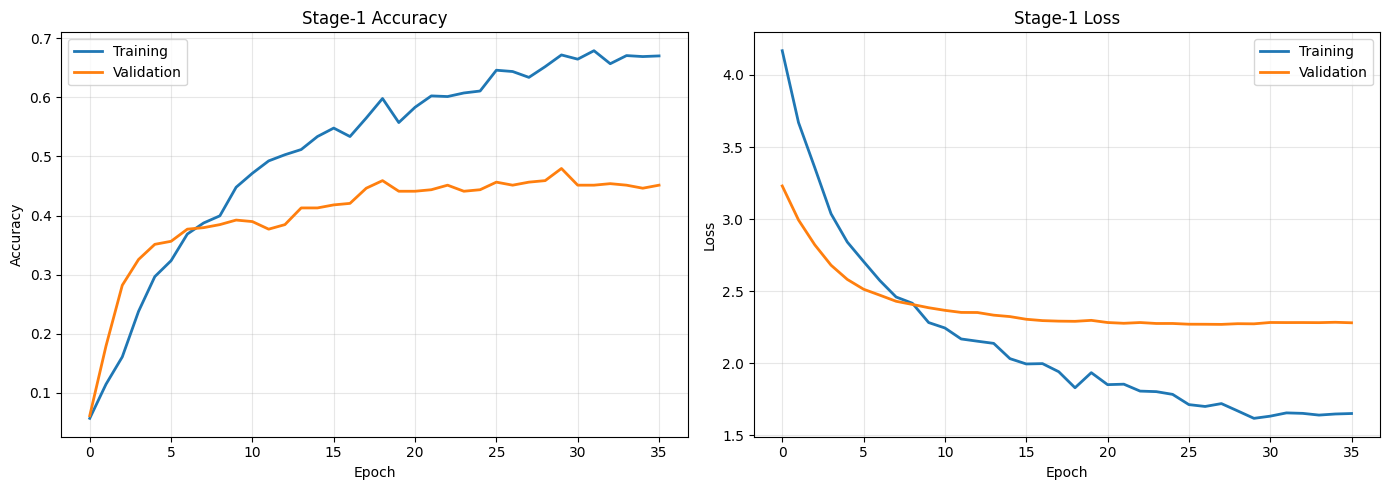

In [26]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation"
)

plt.title("Stage-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation"
)

plt.title("Stage-1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Unfreeze Final Layers

In [27]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-25:]:
    layer.trainable = True

print("=" * 60)
print("Trainable Layers")
print("=" * 60)

trainable_count = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable_count += 1
    print(f"{layer.name:35} : {layer.trainable}")

print("\nTotal Trainable Layers:", trainable_count)

Trainable Layers
input_layer_1                       : False
Conv1                               : False
bn_Conv1                            : False
Conv1_relu                          : False
expanded_conv_depthwise             : False
expanded_conv_depthwise_BN          : False
expanded_conv_depthwise_relu        : False
expanded_conv_project               : False
expanded_conv_project_BN            : False
block_1_expand                      : False
block_1_expand_BN                   : False
block_1_expand_relu                 : False
block_1_pad                         : False
block_1_depthwise                   : False
block_1_depthwise_BN                : False
block_1_depthwise_relu              : False
block_1_project                     : False
block_1_project_BN                  : False
block_2_expand                      : False
block_2_expand_BN                   : False
block_2_expand_relu                 : False
block_2_depthwise                   : False
block_2_depthwi

## Recompile

In [28]:
model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=["accuracy"]
)

## Fine-Tuning

In [29]:
fine_tune_epochs = 15
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.5185 - loss: 2.0920
Epoch 1: val_accuracy improved from 0.47949 to 0.48974, saving model to ../models\mobilenetv2_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 56s 876ms/step - accuracy: 0.5231 - loss: 2.0578 - val_accuracy: 0.4897 - val_loss: 2.2928 - learning_rate: 1.0000e-05
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.5554 - loss: 1.9613
Epoch 2: val_accuracy did not improve from 0.48974
57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 827ms/step - accuracy: 0.5467 - loss: 2.0023 - val_accuracy: 0.4821 - val_loss: 2.3225 - learning_rate: 1.0000e-05
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.5649 - loss: 1.9440
Epoch 3: val_accuracy did not improve from 0.48974

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 828ms/step - accuracy: 0.5582 - loss: 1.9554 - val_accuracy: 0.4641 - val_loss: 2.3488 - learning_rate: 1.0000e-05
Epoch 4/15
57/57 ━━

## Save Final Model

In [30]:
final_model_path = os.path.join(
    MODEL_DIR,
    "mobilenetv2_final.keras"
)

model.save(final_model_path)
print("Final model saved successfully!")

Final model saved successfully!


## Evaluate

In [31]:
loss, accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 50)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")
print("=" * 50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 465ms/step - accuracy: 0.3795 - loss: 2.5236
Test Accuracy : 37.95%
Test Loss     : 2.5236


## Predictions

In [32]:
test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 513ms/step


## Confusion Matrix

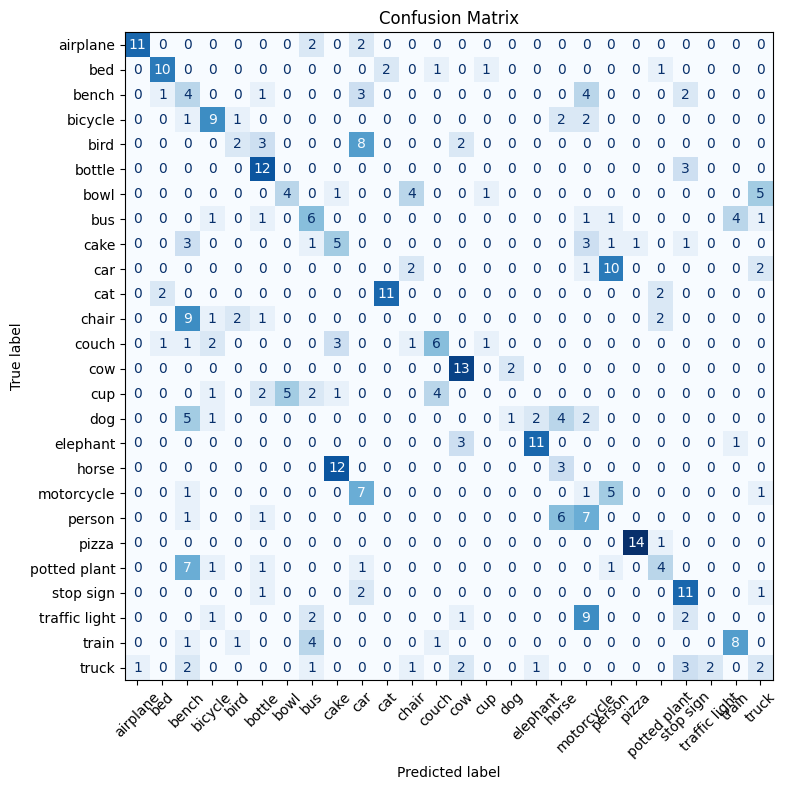

In [33]:
cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

## Classification Report

In [34]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

     airplane       0.92      0.73      0.81        15
          bed       0.71      0.67      0.69        15
        bench       0.11      0.27      0.16        15
      bicycle       0.53      0.60      0.56        15
         bird       0.33      0.13      0.19        15
       bottle       0.52      0.80      0.63        15
         bowl       0.44      0.27      0.33        15
          bus       0.33      0.40      0.36        15
         cake       0.23      0.33      0.27        15
          car       0.00      0.00      0.00        15
          cat       0.85      0.73      0.79        15
        chair       0.00      0.00      0.00        15
        couch       0.50      0.40      0.44        15
          cow       0.62      0.87      0.72        15
          cup       0.00      0.00      0.00        15
          dog       0.33      0.07      0.11        15
     elephant       0.79      0.73      0.76        15
        h

## Fine-Tuning Curves

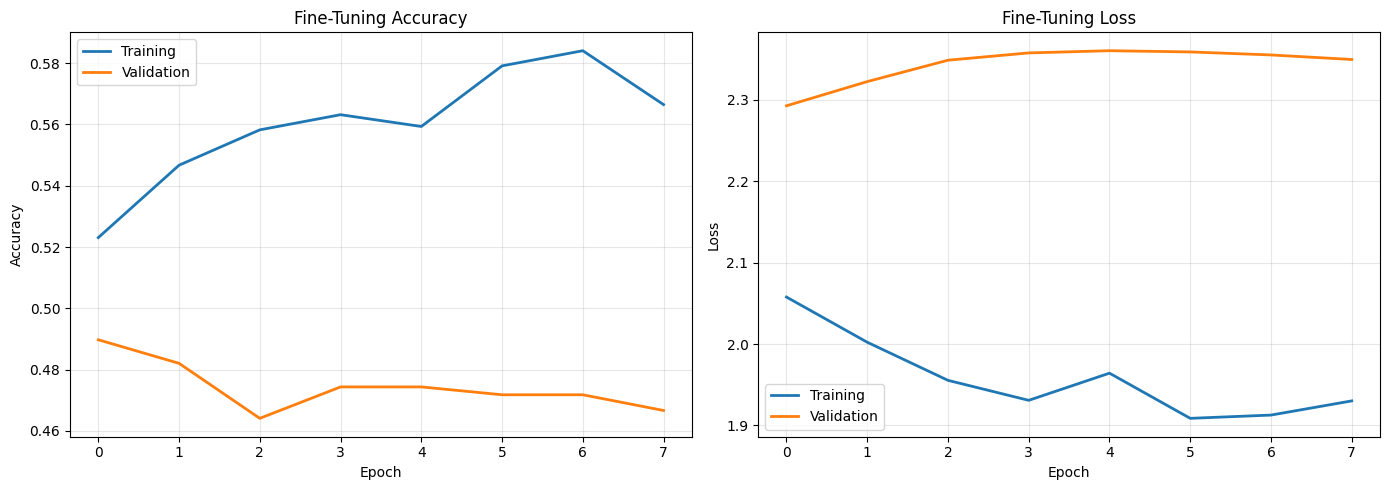

In [35]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    history_fine.history["accuracy"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history_fine.history["val_accuracy"],
    linewidth=2,
    label="Validation"
)

plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)

plt.plot(
    history_fine.history["loss"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history_fine.history["val_loss"],
    linewidth=2,
    label="Validation"
)

plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Training Summary

In [36]:
print("=" * 65)
print("SmartVision V2 - MobileNetV2 Training Complete")
print("=" * 65)

print(f"Number of Classes : {NUM_CLASSES}")
print(f"Image Size        : {IMAGE_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")

print(f"\nFinal Test Accuracy : {accuracy*100:.2f}%")
print(f"Final Test Loss     : {loss:.4f}")

print("\nSaved Models")
print(f"Best Model   : {os.path.join(MODEL_DIR,'mobilenetv2_best.keras')}")
print(f"Stage-1 Model: {os.path.join(MODEL_DIR,'mobilenetv2_stage1.keras')}")
print(f"Final Model  : {os.path.join(MODEL_DIR,'mobilenetv2_final.keras')}")

print("=" * 65)

SmartVision V2 - MobileNetV2 Training Complete
Number of Classes : 26
Image Size        : (224, 224)
Batch Size        : 32

Final Test Accuracy : 37.95%
Final Test Loss     : 2.5236

Saved Models
Best Model   : ../models\mobilenetv2_best.keras
Stage-1 Model: ../models\mobilenetv2_stage1.keras
Final Model  : ../models\mobilenetv2_final.keras
